In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("air_quality.csv")

In [4]:
df.head(20)

,Date,City,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed,AQI
0,2023-01-01,Chennai,107,119,40,46,1.04,68,33,28,4.86,102.0
1,2023-01-02,Bangalore,207,308,23,28,1.53,48,20,57,0.92,199.0
2,2023-01-03,Kolkata,249,273,24,74,0.30,113,22,67,3.53,202.0
3,2023-01-04,Bangalore,153,241,61,27,1.12,108,43,79,2.50,163.0
4,2023-01-05,Bangalore,106,376,22,48,0.82,63,34,82,4.41,174.0
5,2023-01-06,Mumbai,210,42,51,57,0.97,107,16,21,1.30,125.0
6,2023-01-07,Kolkata,133,269,53,64,1.25,64,13,30,3.62,161.0
7,2023-01-08,Kolkata,196,29,18,49,1.05,33,17,83,4.27,105.0
8,2023-01-09,Kolkata,268,265,19,62,1.13,31,29,40,4.75,206.0
9,2023-01-10,Bangalore,157,344,35,27,1.02,78,38,37,3.57,189.0


In [5]:
numeric_cols = [
    "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
    "Temperature", "Humidity", "WindSpeed", "AQI"]

In [6]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)


In [7]:
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


Missing Values Before Cleaning:
Date           116
City             0
PM2.5            0
PM10             0
NO2              0
SO2              0
CO               0
O3               0
Temperature      0
Humidity         0
WindSpeed        0
AQI              0
dtype: int64


In [8]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df["City"] = df["City"].fillna(df["City"].mode()[0])


In [9]:
df = df[(df["AQI"] >= 0) & (df["AQI"] <= 500)]

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
Date           116
City             0
PM2.5            0
PM10             0
NO2              0
SO2              0
CO               0
O3               0
Temperature      0
Humidity         0
WindSpeed        0
AQI              0
dtype: int64


In [10]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

In [11]:
df["AQI_Category"] = df["AQI"].apply(categorize_aqi)

print("\nAQI Category Count:")


AQI Category Count:


In [12]:
df["AQI_Category"] = df["AQI"].apply(categorize_aqi)

print("\nAQI Category Count:")


AQI Category Count:



Average AQI by City:
City
Kolkata      155.729730
Bangalore    154.111111
Mumbai       150.114286
Delhi        149.348837
Chennai      147.122449
Name: AQI, dtype: float64


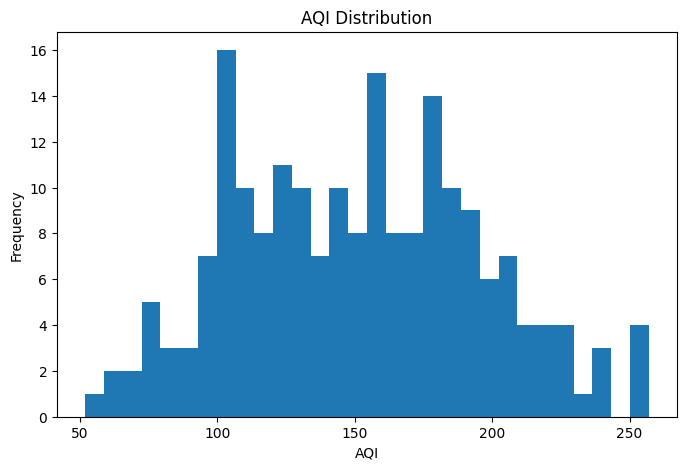

In [13]:
print("\nAverage AQI by City:")
print(df.groupby("City")["AQI"].mean().sort_values(ascending=False))

plt.figure(figsize=(8, 5))
plt.hist(df["AQI"], bins=30)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

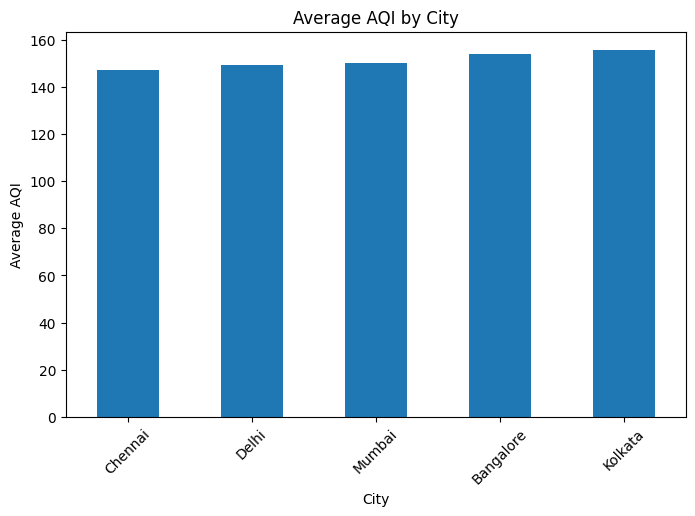

In [14]:
city_aqi = df.groupby("City")["AQI"].mean().sort_values()

plt.figure(figsize=(8, 5))
city_aqi.plot(kind="bar")
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()


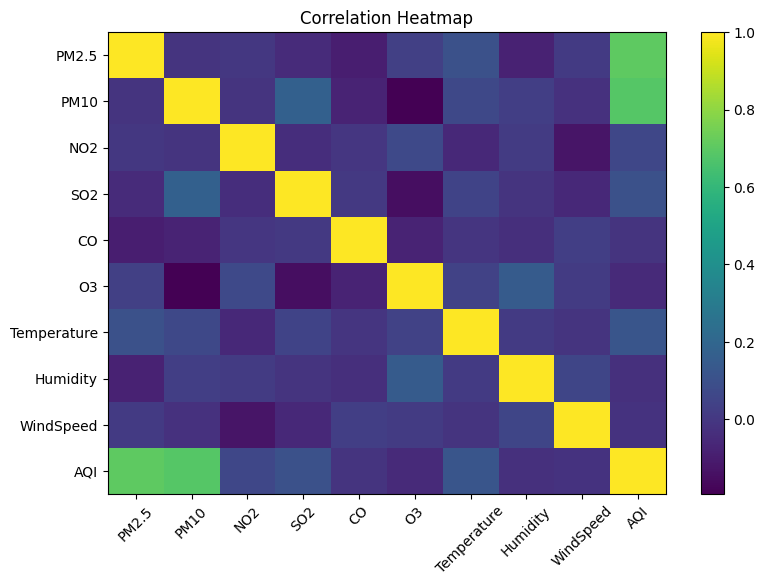

In [15]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
print("\nCorrelation with AQI:")
print(corr["AQI"].sort_values(ascending=False))



Correlation with AQI:
AQI            1.000000
PM2.5          0.703734
PM10           0.686314
Temperature    0.120476
SO2            0.104332
NO2            0.060033
CO            -0.012982
WindSpeed     -0.016388
Humidity      -0.027796
O3            -0.050762
Name: AQI, dtype: float64


In [17]:
features = [
    "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
    "Temperature", "Humidity", "WindSpeed"
]


In [18]:
X = df[features]
y = df["AQI"]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)


In [21]:
print("\nLinear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("MSE:", mean_squared_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R2 Score:", r2_score(y_test, linear_pred))


Linear Regression Performance:
MAE: 0.22911827939451043
MSE: 0.07105321240123645
RMSE: 0.26655808447923024
R2 Score: 0.9999467561798808


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [23]:
print("\nRandom Forest Performance:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))



Random Forest Performance:
MAE: 9.72975
MSE: 151.5590775
RMSE: 12.310933250570406
R2 Score: 0.8864290017703426


In [25]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": rf_pred
})

print("\nActual vs Predicted AQI:")
print(comparison.head(10))



Actual vs Predicted AQI:
   Actual AQI  Predicted AQI
0       128.0         125.83
1       103.0          88.14
2       149.0         126.84
3       114.0         111.51
4       160.0         168.36
5       147.0         139.54
6       169.0         177.70
7       136.0         124.14
8       103.0         105.99
9       195.0         206.33


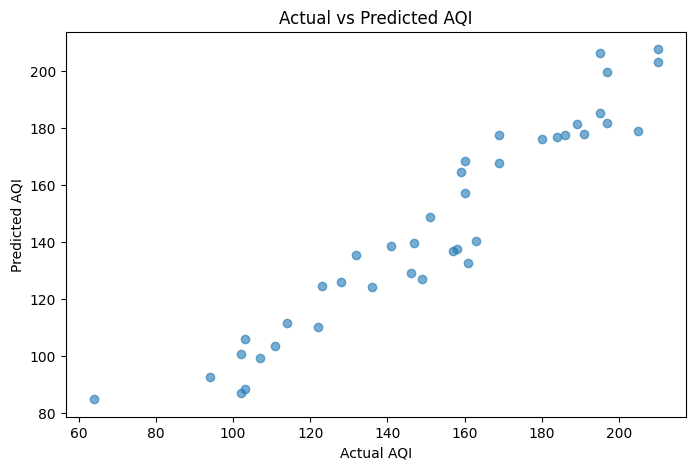

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

In [27]:
new_data = pd.DataFrame({
    "PM2.5": [180],
    "PM10": [350],
    "NO2": [45],
    "SO2": [12],
    "CO": [0.9],
    "O3": [30],
    "Temperature": [28],
    "Humidity": [65],
    "WindSpeed": [2.3]
})


In [28]:
predicted_aqi = rf_model.predict(new_data)[0]
predicted_category = categorize_aqi(predicted_aqi)

print("\nNew Data Prediction:")
print("Predicted AQI:", round(predicted_aqi, 2))
print("Predicted AQI Category:", predicted_category)



New Data Prediction:
Predicted AQI: 182.88
Predicted AQI Category: Moderate


In [29]:
df.to_csv("Modified_airquality_Data.csv", index=False)

print("\nCleaned dataset saved")


Cleaned dataset saved
